In [1]:
import os
import time, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

` rsync -avu nexusgateway:/mnt/NexusData/Bridge/Temperature_20220419.txt ./`

In [2]:
date  = "20240726"

fname = "Temperature_" + date + ".txt"
fpath = "/data/SlowDataLogCopies"#"/home/nexus-admin/Downloads"
path  = os.path.join(fpath,fname)

In [3]:
## Extract the header column names
col_names = None
with open(path,"r") as f:
    col_names = f.readline().split()
print(col_names)

['Channel', 'Measurement', 'Resistance', 'Temperature', 'Res', 'Range', 'Excitation', 'Time', 'ControlSetup', 'ControlChannel', 'CurveName', 'HeaterRange', 'PID_P', 'PID_I', 'PID_D', 'SetupUnit', 'SetPoint', 'HeatResistance', 'HeaterPower']


In [4]:
## Create an empty dataframe with column names
df = pd.DataFrame(columns=col_names)

In [5]:
with open(path,"r") as f:
    ## Get all the lines in the files
    lines = f.readlines()
    
    ## Count the number of lines in the file 
    nline = len(lines)
    
    ## Loop over all rows in file, skipping the first
    for i in 1+np.arange(nline-1):
        
        ## Parse the line
        line = None
        line = np.array(lines[i].split("\t"))
        l1t  = np.append(line[0:4] , line[4].split())
        line = np.append( l1t, line[5:])
        line[3] = line[3].replace("K","")
        
        ## Make sure the line has the right number of entries
        if len(line) != len(col_names):
            line = np.append(line, np.empty((len(col_names)-len(line),1), dtype=str))
        
        ## Add row to end of DataFrame
        df.loc[len(df.index)] = line

In [6]:
def timeConvert(tstr):
    return time.mktime(datetime.datetime.strptime(tstr.strip(), "%Y-%m-%d %H:%M:%S.%f").timetuple())
    
df["Tstamp"] = df["Time"].apply(timeConvert)

In [7]:
df

,Channel,Measurement,Resistance,Temperature,Res,Range,Excitation,Time,ControlSetup,ControlChannel,CurveName,HeaterRange,PID_P,PID_I,PID_D,SetupUnit,SetPoint,HeatResistance,HeaterPower,Tstamp
0,13,PT Fridge Touch Sensor Resistor(50 kOhm),37210.8 Ohms,N/A,63.2,kOhms,2.00 uV,2024-07-26 05:00:08.661\n,,,,,,,,,,,,1.721988e+09
1,4,RF Payload Therm TT2101,16553.5 Ohms,0.053427,20.0,kOhms,6.32 uV,2024-07-26 05:00:17.484\n,,,,,,,,,,,,1.721988e+09
2,5,DC Tower Therm Soudan#12,2777.19 Ohms,0.047454,6.32,kOhms,6.32 uV,2024-07-26 05:00:26.192\n,,,,,,,,,,,,1.721988e+09
3,11,SQUID Board Therm Soudan#11,2065.46 Ohms,0.175974,6.32,kOhms,20.0 uV,2024-07-26 05:00:34.870\n,,,,,,,,,,,,1.721988e+09
4,13,PT Fridge Touch Sensor Resistor(50 kOhm),37202.7 Ohms,N/A,63.2,kOhms,2.00 uV,2024-07-26 05:00:43.530\n,,,,,,,,,,,,1.721988e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4911,13,PT Fridge Touch Sensor Resistor(50 kOhm),50909.9 Ohms,N/A,63.2,kOhms,2.0 mV,2024-07-26 16:36:54.036\n,,,,,,,,,,,,1.722030e+09
4912,13,PT Fridge Touch Sensor Resistor(50 kOhm),50838.6 Ohms,N/A,63.2,kOhms,2.0 mV,2024-07-26 16:36:58.686\n,,,,,,,,,,,,1.722030e+09
4913,13,PT Fridge Touch Sensor Resistor(50 kOhm),50665.6 Ohms,N/A,63.2,kOhms,2.0 mV,2024-07-26 16:37:03.335\n,,,,,,,,,,,,1.722030e+09
4914,13,PT Fridge Touch Sensor Resistor(50 kOhm),50444.5 Ohms,N/A,63.2,kOhms,2.0 mV,2024-07-26 16:37:07.995\n,,,,,,,,,,,,1.722030e+09


In [8]:
set(df["Channel"])

{'11', '13', '4', '5'}

In [9]:
df[ df["Channel"] == "4" ]

,Channel,Measurement,Resistance,Temperature,Res,Range,Excitation,Time,ControlSetup,ControlChannel,CurveName,HeaterRange,PID_P,PID_I,PID_D,SetupUnit,SetPoint,HeatResistance,HeaterPower,Tstamp
1,4,RF Payload Therm TT2101,16553.5 Ohms,0.053427,20.0,kOhms,6.32 uV,2024-07-26 05:00:17.484\n,,,,,,,,,,,,1.721988e+09
5,4,RF Payload Therm TT2101,16484.1 Ohms,0.053739,20.0,kOhms,6.32 uV,2024-07-26 05:00:52.320\n,,,,,,,,,,,,1.721988e+09
9,4,RF Payload Therm TT2101,16544.4 Ohms,0.053468,20.0,kOhms,6.32 uV,2024-07-26 05:01:27.150\n,,,,,,,,,,,,1.721988e+09
13,4,RF Payload Therm TT2101,16497.1 Ohms,0.053681,20.0,kOhms,6.32 uV,2024-07-26 05:02:02.004\n,,,,,,,,,,,,1.721988e+09
17,4,RF Payload Therm TT2101,16427.6 Ohms,0.053993,20.0,kOhms,6.32 uV,2024-07-26 05:02:36.878\n,,,,,,,,,,,,1.721988e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4649,4,RF Payload Therm TT2101,16840.4 Ohms,0.052136,20.0,kOhms,6.32 uV,2024-07-26 16:15:10.947\n,,,,,,,,,,,,1.722029e+09
4653,4,RF Payload Therm TT2101,16810.3 Ohms,0.052271,20.0,kOhms,6.32 uV,2024-07-26 16:15:45.747\n,,,,,,,,,,,,1.722029e+09
4657,4,RF Payload Therm TT2101,16877.8 Ohms,0.051967,20.0,kOhms,6.32 uV,2024-07-26 16:16:20.566\n,,,,,,,,,,,,1.722029e+09
4661,4,RF Payload Therm TT2101,17003.5 Ohms,0.051402,20.0,kOhms,6.32 uV,2024-07-26 16:16:55.364\n,,,,,,,,,,,,1.722029e+09


In [10]:
def plotChannel(chan, fig_obj=None, label=None):
    
    ## Ensure we're looking at strings only
    if not (type(chan)==type("s")):
        chan = str(chan)
        
    ## Get the dataframe entries for this channel
    chan_df = df[ df["Channel"] == chan ]
    
    ## Get the data to plot
    t_vals = chan_df["Tstamp"].to_numpy().astype(type(1.1))      ## Epoch seconds
    T_vals = chan_df["Temperature"].to_numpy()                   ## Kelvin
    
    ## Clean and recast the data of interest
    T_vals[ T_vals == 'Out of Range' ] = np.nan
    T_vals    = 1000.0 * T_vals.astype(type(1.1))                ## milliKelvin
    t_vals_dt = np.vectorize(datetime.datetime.fromtimestamp)(t_vals-5*3600)
    
    ## Create the plot
    if fig_obj is None:
        fig = plt.figure()
    ax0 = fig_obj.gca()
    ax0.set_xlabel("Time")
    ax0.set_ylabel("Temperature [mK]")
    
    ## Draw the line
    ax0.plot(t_vals_dt,T_vals,label=label)
    
    ## Change the time format
    ax0.xaxis.set_major_formatter( DateFormatter('%H:%M:%S') )
    for tick in ax0.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('right')
        tick.set_rotation(30)

    return fig_obj, ax0

<IPython.core.display.Javascript object>


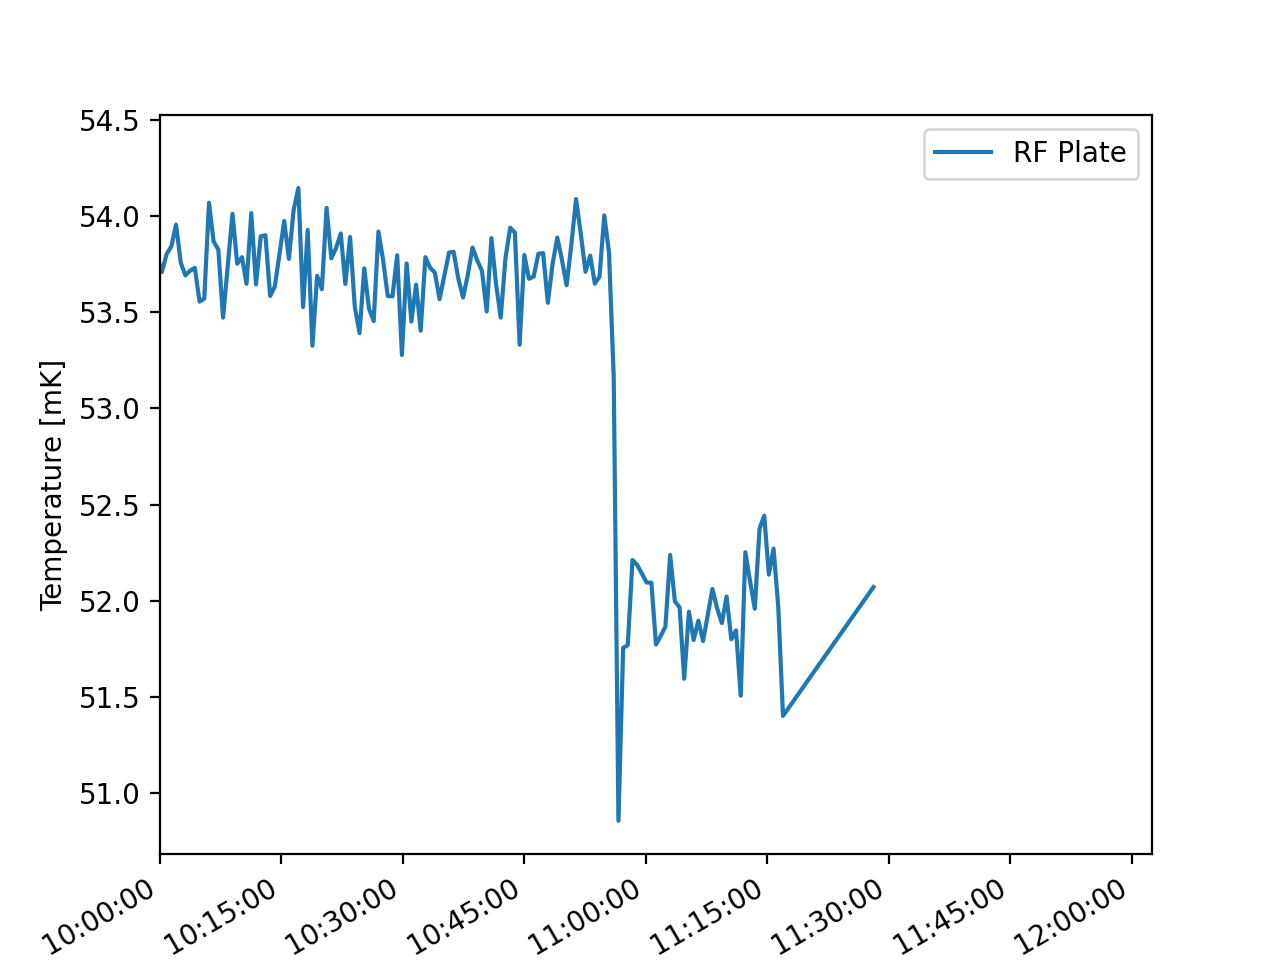

(19930.416666666668, 19930.501717592593)

In [11]:
%matplotlib notebook
fig = plt.figure()
plotChannel(4,fig_obj=fig,label="RF Plate")
plt.legend()

xlim = plt.gca().get_xlim()
plt.gca().set_xlim([datetime.datetime(2024,7,26,10,0,0) , xlim[1]])